# Imports

In [5]:
from multimodal_fin.financial.pipeline import EventPipeline
from multimodal_fin.financial.price_preprocessor import PricePreprocessor

# Preprocess

In [6]:
price_file = "../data/financial/price_2019_2025.csv"
companies_folder = "../data/financial/companies_closes"
conference_file = "../data/financial/conference_data.csv"

preprocessor = PricePreprocessor(price_file, companies_folder)

pipeline = EventPipeline(
    conference_file=conference_file,
    prices_folder=companies_folder,
    market_ticker="SPGI" # S&P500 index as market model, it could be NASDAQ e.g if data is available
)

In [7]:
# Divide stock data into individual ticker files

preprocessor.split_by_ticker()

2026-01-06 19:46:53 - multimodal_fin.financial.price_preprocessor - INFO - Loading master price file: ../data/financial/price_2019_2025.csv
2026-01-06 19:46:53 - multimodal_fin.financial.price_preprocessor - INFO - Found 217 unique tickers.
2026-01-06 19:46:56 - multimodal_fin.financial.price_preprocessor - INFO - Finished splitting dataset into 217 CSV files.


# Calculate events

In [8]:
# events = pipeline.run(ticker_filter="AMZN")             # Just this company
# events = pipeline.run(ticker_filter=["AMZN", "AAPL"])   # This N companies
events = pipeline.run()                                 # All companies

2026-01-06 19:46:56 - multimodal_fin.financial.calculator - ERROR - [AAPL] No stock data in estimation window for event: Q3 2018 
2026-01-06 19:46:56 - multimodal_fin.financial.calculator - ERROR - [AAPL] No stock data in estimation window for event: Q4 2018 
2026-01-06 19:46:56 - multimodal_fin.financial.calculator - ERROR - [AAPL] No stock data in estimation window for event: Q1 2019 
2026-01-06 19:46:57 - multimodal_fin.financial.company_events - WARNING - [ABT] Skipping 2021-02-09: -17 days available (< 30)
2026-01-06 19:46:57 - multimodal_fin.financial.calculator - ERROR - [ACN] No stock data in estimation window for event: Q1 2019 
2026-01-06 19:46:57 - multimodal_fin.financial.calculator - ERROR - [ADBE] No stock data in estimation window for event: Q4 2018 
2026-01-06 19:46:58 - multimodal_fin.financial.calculator - ERROR - [AMD] No stock data in estimation window for event: Q4 2018 
2026-01-06 19:46:58 - multimodal_fin.financial.calculator - ERROR - [AMD] No stock data in esti

In [9]:
# List events for a company

pipeline.list_company_events("AAPL")

             📊 Events for Apple Inc. (AAPL)             
┏━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃    Date    ┃ Quarter ┃ Year ┃      Event Window       ┃
┡━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 2018-07-31 │   Q3    │ 2018 │ 2018-07-24 → 2018-08-07 │
├────────────┼─────────┼──────┼─────────────────────────┤
│ 2018-11-01 │   Q4    │ 2018 │ 2018-10-25 → 2018-11-08 │
├────────────┼─────────┼──────┼─────────────────────────┤
│ 2019-01-29 │   Q1    │ 2019 │ 2019-01-22 → 2019-02-05 │
├────────────┼─────────┼──────┼─────────────────────────┤
│ 2019-04-30 │   Q2    │ 2019 │ 2019-04-23 → 2019-05-07 │
├────────────┼─────────┼──────┼─────────────────────────┤
│ 2019-07-30 │   Q3    │ 2019 │ 2019-07-23 → 2019-08-06 │
├────────────┼─────────┼──────┼─────────────────────────┤
│ 2019-10-30 │   Q4    │ 2019 │ 2019-10-23 → 2019-11-06 │
├────────────┼─────────┼──────┼─────────────────────────┤
│ 2020-04-30 │   Q2    │ 2020 │ 2020-04-23 → 2020-05-07 │
├────────────┼─────────┼──────┼─────────────────────────┤
│ 2021-01-27 │   Q1    │ 2021 │ 2021-01-20 → 2021-02-03 │
├────────────┼─────────┼──────┼─────────────────────────┤
│ 2021-04-28 │   Q2    │ 2021 │ 2021-04-21 → 2021-05-05 │
├────────────┼─────────┼──────┼─────────────────────────┤
│ 2021-07-27 │   Q3    │ 2021 │ 2021-07-20 → 2021-08-03 │
├────────────┼─────────┼──────┼─────────────────────────┤
│ 2021-10-28 │   Q4    │ 2021 │ 2021-10-21 → 2021-11-04 │
├────────────┼─────────┼──────┼─────────────────────────┤
│ 2022-01-27 │   Q1    │ 2022 │ 2022-01-20 → 2022-02-03 │
├────────────┼─────────┼──────┼─────────────────────────┤
│ 2022-04-28 │   Q2    │ 2022 │ 2022-04-21 → 2022-05-05 │
├────────────┼─────────┼──────┼─────────────────────────┤
│ 2022-07-28 │   Q3    │ 2022 │ 2022-07-21 → 2022-08-04 │
├────────────┼─────────┼──────┼─────────────────────────┤
│ 2022-10-27 │   Q4    │ 2022 │ 2022-10-20 → 2022-11-03 │
├────────────┼─────────┼──────┼─────────────────────────┤
│ 2023-02-02 │   Q1    │ 2023 │ 2023-01-26 → 2023-02-09 │
├────────────┼─────────┼──────┼─────────────────────────┤
│ 2023-05-04 │   Q2    │ 2023 │ 2023-04-27 → 2023-05-11 │
├────────────┼─────────┼──────┼─────────────────────────┤
│ 2023-08-03 │   Q3    │ 2023 │ 2023-07-27 → 2023-08-10 │
├────────────┼─────────┼──────┼─────────────────────────┤
│ 2023-11-03 │   Q4    │ 2023 │ 2023-10-27 → 2023-11-10 │
├────────────┼─────────┼──────┼─────────────────────────┤
│ 2024-02-01 │   Q1    │ 2024 │ 2024-01-25 → 2024-02-08 │
└────────────┴─────────┴──────┴─────────────────────────┘

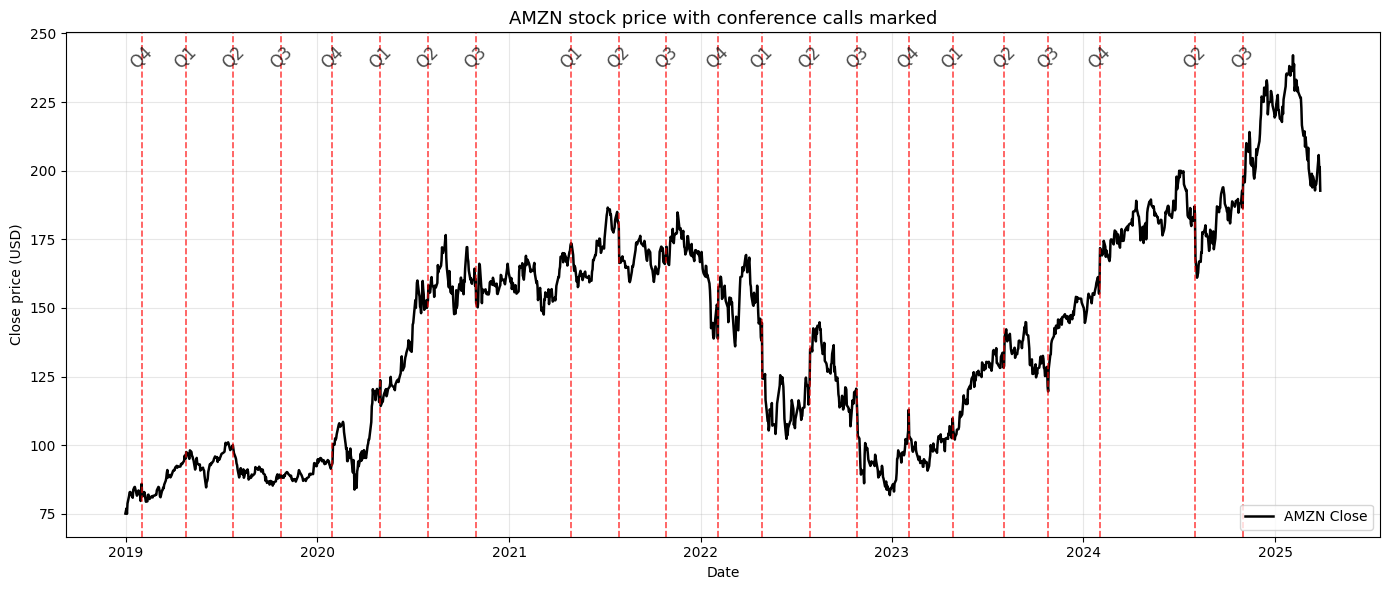

2026-01-06 19:47:30 - multimodal_fin.financial.pipeline - INFO - [AMZN] Plotted stock evolution with 22 conference markers from 2018-12-31 to 2025-03-28.


In [10]:
# Visualize stock price evolution with conference events

pipeline.plot_stock_conferences_evolution(
    ticker="AMZN",
    show_quarters=True
)


📅 Event: 2023-04-27 (AMZN)
Company: Amazon.com, Inc.
Estimation window: 2023-01-26 → 2023-03-21 (gap=30)
Alpha: 0.002870
Beta: 1.103045
CAR [-7,7]: -2.0197%


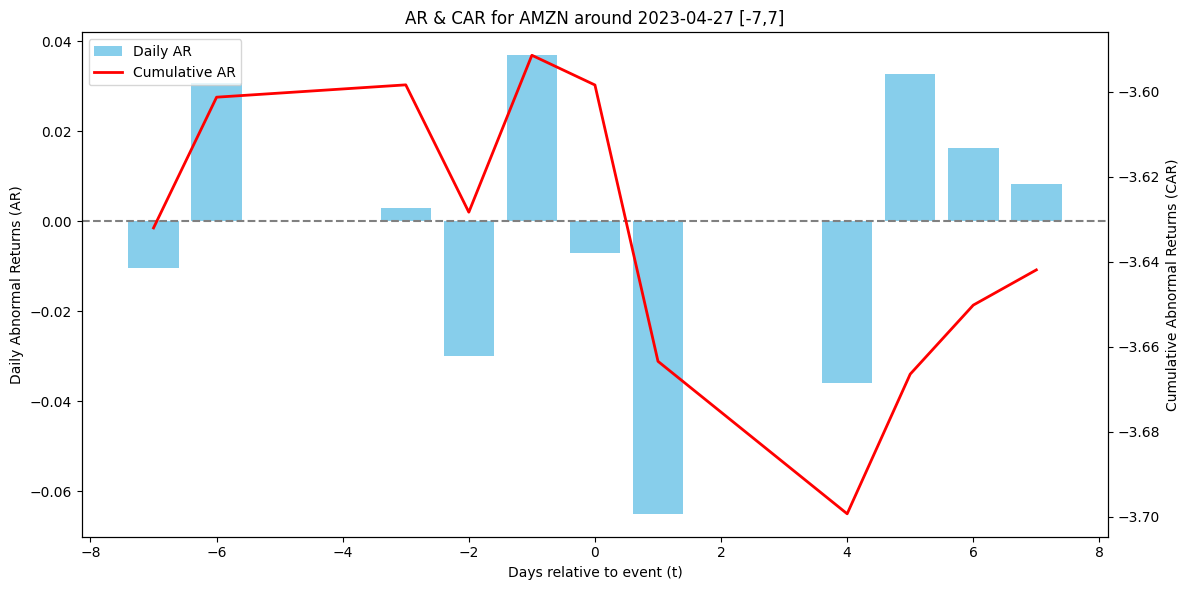

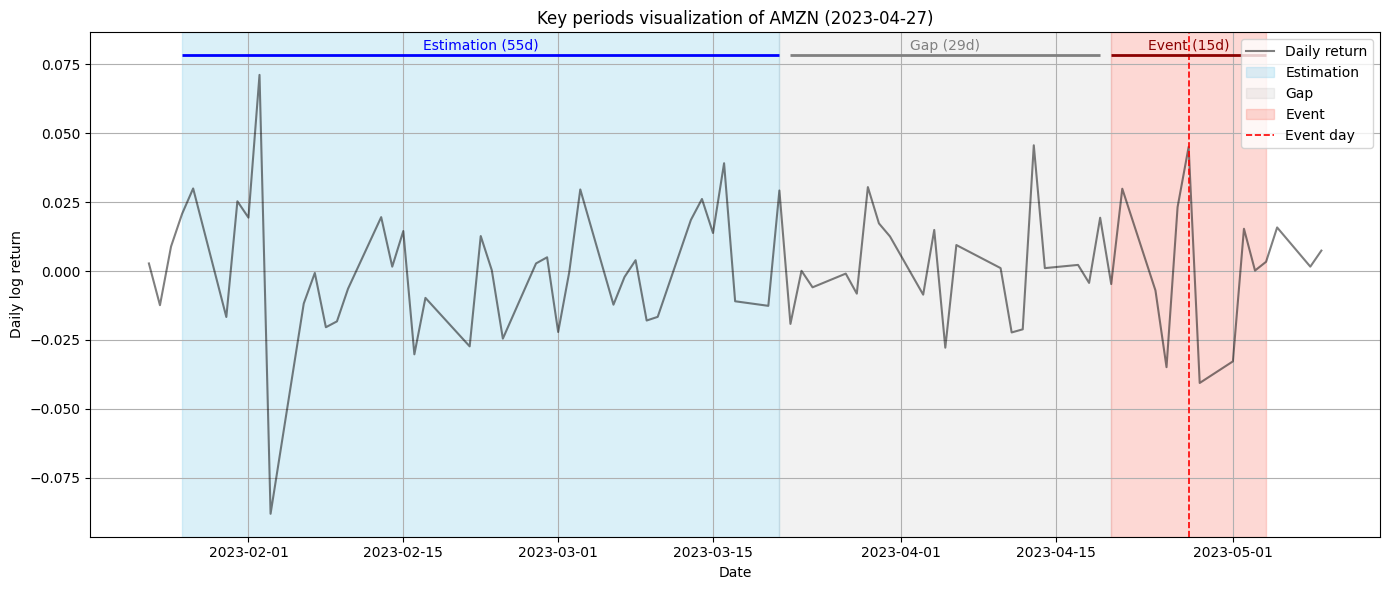

In [11]:
# Visualize a specific event with CAR analysis

pipeline.get_event("AMZN", year=2023, quarter='Q1', events=events).report(plot_config={"plot_car": True, "plot_periods": True})

# Analyze statistical significance

In [12]:
df_car, summary = pipeline.analyze_significance(events=events, car_window=(-7, 7), plot=False)
summary

2026-01-06 19:47:30 - multimodal_fin.financial.pipeline - INFO - Multiple tickers detected: ['AAPL', 'ABBV', 'ABNB', 'ABT', 'ACN', 'ADBE', 'ADP', 'AEP', 'ALB', 'AMAT', 'AMD', 'AMGN', 'AMT', 'AMZN', 'APD', 'AVB', 'AVGO', 'AWK', 'AXP', 'AZO', 'BA', 'BAC', 'BKNG', 'BKR', 'BLK', 'BMY', 'BSX', 'BX', 'C', 'CAT', 'CB', 'CBRE', 'CCI', 'CEG', 'CF', 'CHD', 'CHTR', 'CI', 'CL', 'CMCSA', 'CMG', 'COP', 'COST', 'CRM', 'CSCO', 'CSGP', 'CSX', 'CTAS', 'CTRA', 'CTVA', 'CVX', 'D', 'DD', 'DE', 'DHI', 'DHR', 'DIS', 'DLR', 'DOW', 'DTE', 'DUK', 'DVN', 'EA', 'ECL', 'EIX', 'ELV', 'EMN', 'EMR', 'EOG', 'EQIX', 'EQR', 'EQT', 'ESS', 'ETN', 'ETR', 'EXC', 'EXR', 'F', 'FANG', 'FCX', 'FI', 'FOXA', 'GD', 'GE', 'GEV', 'GILD', 'GIS', 'GM', 'GOOG', 'GS', 'HAL', 'HD', 'HES', 'HLT', 'HON', 'IBM', 'ICE', 'IFF', 'INTU', 'IPG', 'IRM', 'ISRG', 'ITW', 'JNJ', 'JPM', 'KDP', 'KHC', 'KKR', 'KMB', 'KMI', 'KO', 'KR', 'KVUE', 'LIN', 'LLY', 'LMT', 'LOW', 'LYB', 'LYV', 'MA', 'MAR', 'MCD', 'MCK', 'MDLZ', 'MDT', 'META', 'MLM', 'MMC', 'MMM',

,ticker,car_window,mean_CAR,std_CAR,t_stat,p_value,n_events
0,AAPL,"(-7, 7)",0.004246,0.054488,0.321260,0.752172,17
1,ABBV,"(-7, 7)",0.006000,0.066663,0.392350,0.699406,19
2,ABNB,"(-7, 7)",-0.050436,0.137576,-1.321815,0.210874,13
3,ABT,"(-7, 7)",0.017845,0.043508,1.923830,0.068036,22
4,ACN,"(-7, 7)",0.001689,0.059131,0.124516,0.902287,19
...,...,...,...,...,...,...,...
210,WMB,"(-7, 7)",0.009414,0.044406,0.821051,0.425378,15
211,WMT,"(-7, 7)",-0.006742,0.075380,-0.399980,0.693632,20
212,WY,"(-7, 7)",0.011018,0.045615,0.903791,0.382549,14
213,XEL,"(-7, 7)",0.004712,0.041265,0.535541,0.597903,22


# Analyze statistical significance in short-term and medium-term 

In [13]:
import copy
import pandas as pd

windows = [(-7, 7), (-7, 30), (-7, 60), (-7, 90)]

all_summaries = []

for window in windows:
    
    events_copy = copy.deepcopy(events)

    for ev in events_copy:
        try:
            pipeline.calculator.analyze_event(ev, window_to_report=window)
        except Exception as ex:
            print(f"⚠️ Error recalculating event {ev.ticker} ({ev.event_date.date()}): {ex}")
    
    df_car, summary = pipeline.analyze_significance(events=events_copy, car_window=window, plot=False)
    summary["car_window"] = str(window)
    all_summaries.append(summary)

summary_all = pd.concat(all_summaries, ignore_index=True)
summary_all

2026-01-06 19:47:32 - multimodal_fin.financial.calculator - ERROR - [AAPL] No stock data in estimation window for event: Q3 2018 
2026-01-06 19:47:32 - multimodal_fin.financial.calculator - ERROR - [AAPL] No stock data in estimation window for event: Q4 2018 
2026-01-06 19:47:32 - multimodal_fin.financial.calculator - ERROR - [AAPL] No stock data in estimation window for event: Q1 2019 
2026-01-06 19:47:32 - multimodal_fin.financial.calculator - ERROR - [ACN] No stock data in estimation window for event: Q1 2019 
2026-01-06 19:47:33 - multimodal_fin.financial.calculator - ERROR - [ADBE] No stock data in estimation window for event: Q4 2018 
2026-01-06 19:47:33 - multimodal_fin.financial.calculator - ERROR - [AMD] No stock data in estimation window for event: Q4 2018 
2026-01-06 19:47:33 - multimodal_fin.financial.calculator - ERROR - [AMD] No stock data in estimation window for event: Q1 2019 
2026-01-06 19:47:34 - multimodal_fin.financial.calculator - ERROR - [AMZN] No stock data in e

,ticker,car_window,mean_CAR,std_CAR,t_stat,p_value,n_events
0,AAPL,"(-7, 7)",0.004246,0.054488,0.321260,0.752172,17
1,ABBV,"(-7, 7)",0.006000,0.066663,0.392350,0.699406,19
2,ABNB,"(-7, 7)",-0.050436,0.137576,-1.321815,0.210874,13
3,ABT,"(-7, 7)",0.017845,0.043508,1.923830,0.068036,22
4,ACN,"(-7, 7)",0.001689,0.059131,0.124516,0.902287,19
...,...,...,...,...,...,...,...
855,WMB,"(-7, 90)",0.033556,0.150565,0.863161,0.402594,15
856,WMT,"(-7, 90)",0.003765,0.164756,0.102208,0.919663,20
857,WY,"(-7, 90)",0.001536,0.166843,0.034443,0.973047,14
858,XEL,"(-7, 90)",0.022321,0.128635,0.813886,0.424843,22


# Study companies with evicende

In [14]:
summary_all[summary_all['p_value'] <= 0.05]

,ticker,car_window,mean_CAR,std_CAR,t_stat,p_value,n_events
73,ETN,"(-7, 7)",0.035730,0.043596,3.665206,0.001645,20
97,IFF,"(-7, 7)",-0.088356,0.088690,-2.817783,0.025855,8
138,NEM,"(-7, 7)",-0.041889,0.074815,-2.168508,0.047837,15
157,PH,"(-7, 7)",0.051270,0.077158,3.045018,0.006393,21
850,WBD,"(-7, 90)",0.185279,0.189841,3.086272,0.013008,10


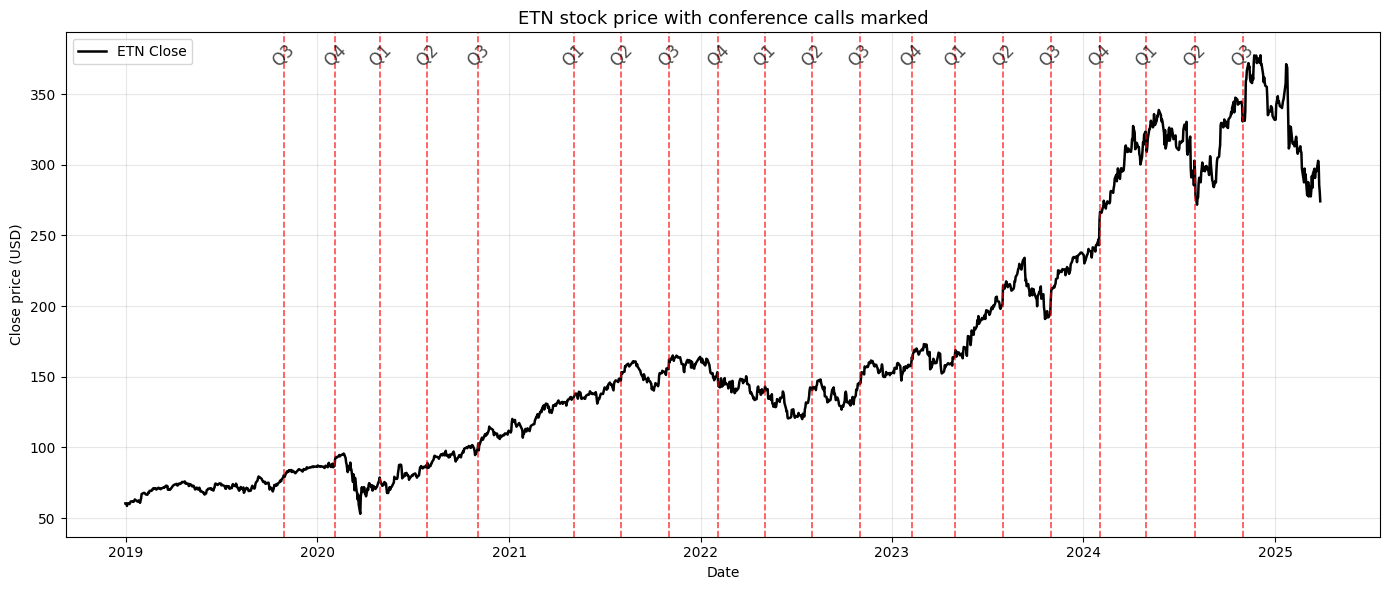

2026-01-06 19:49:51 - multimodal_fin.financial.pipeline - INFO - [ETN] Plotted stock evolution with 20 conference markers from 2018-12-31 to 2025-03-28.


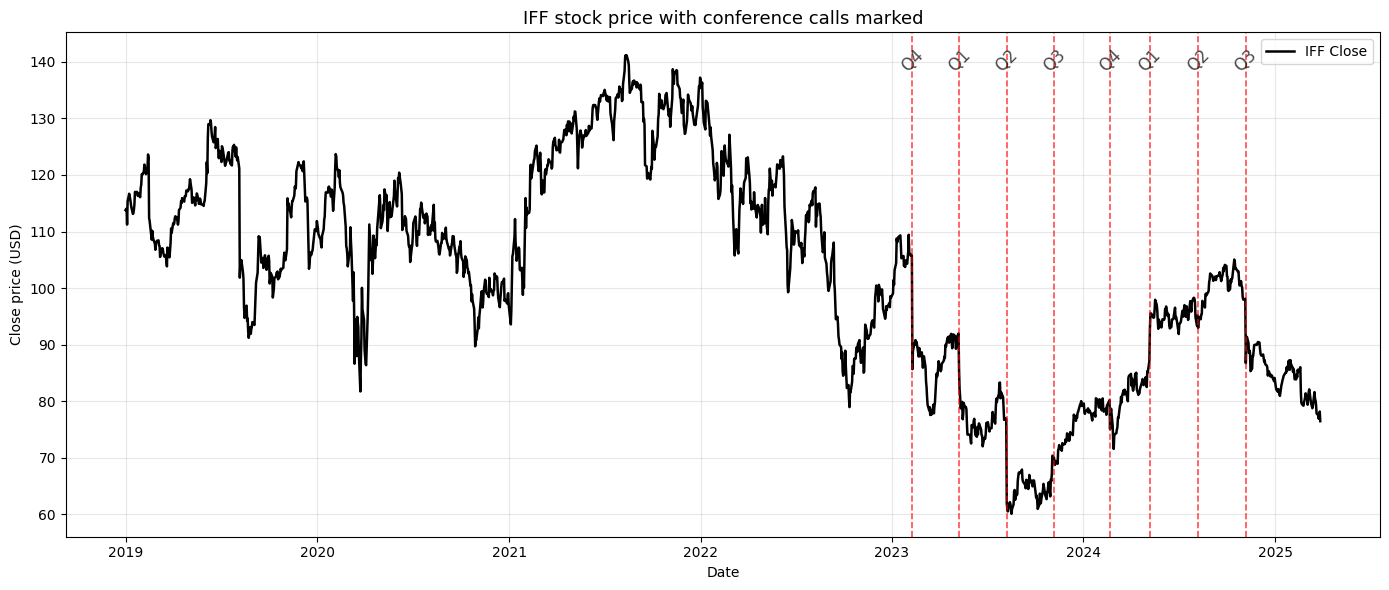

2026-01-06 19:49:51 - multimodal_fin.financial.pipeline - INFO - [IFF] Plotted stock evolution with 8 conference markers from 2018-12-31 to 2025-03-28.


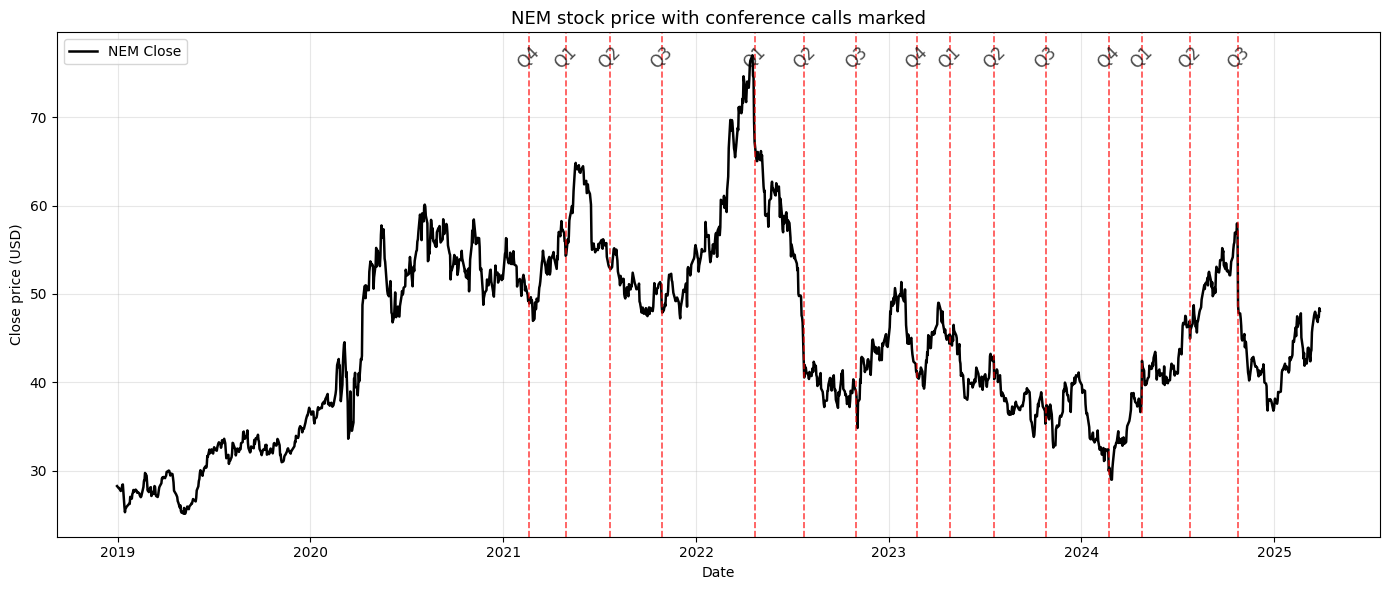

2026-01-06 19:49:51 - multimodal_fin.financial.pipeline - INFO - [NEM] Plotted stock evolution with 15 conference markers from 2018-12-31 to 2025-03-28.


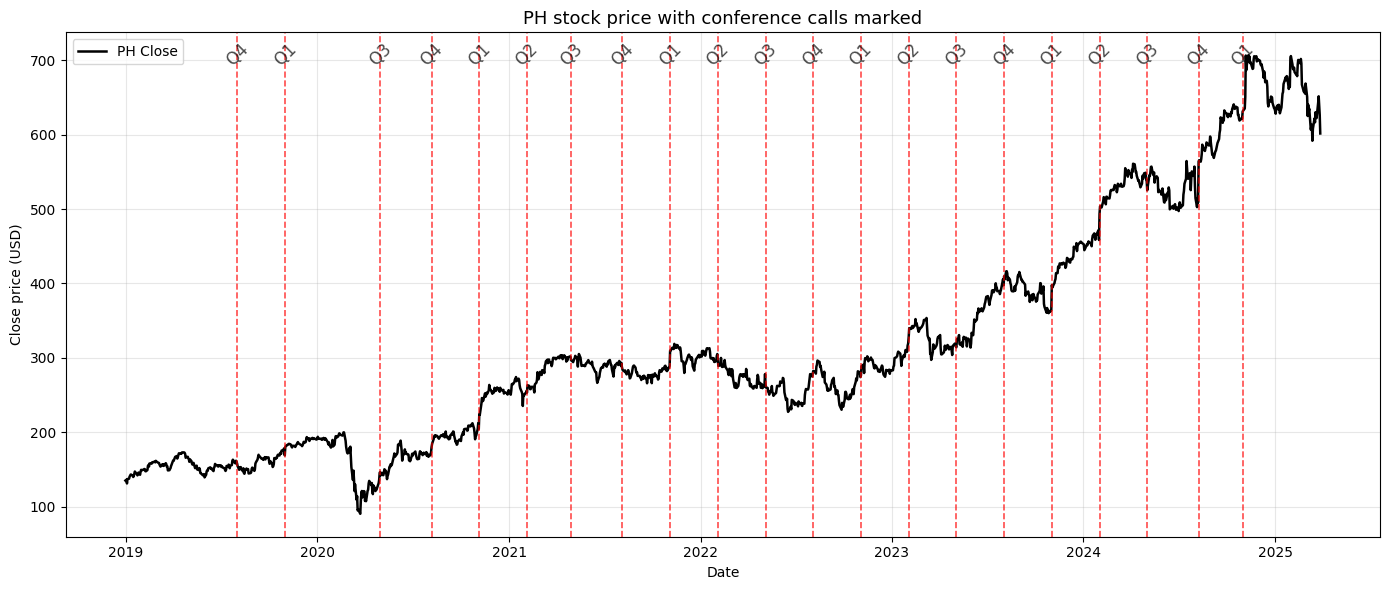

2026-01-06 19:49:51 - multimodal_fin.financial.pipeline - INFO - [PH] Plotted stock evolution with 21 conference markers from 2018-12-31 to 2025-03-28.


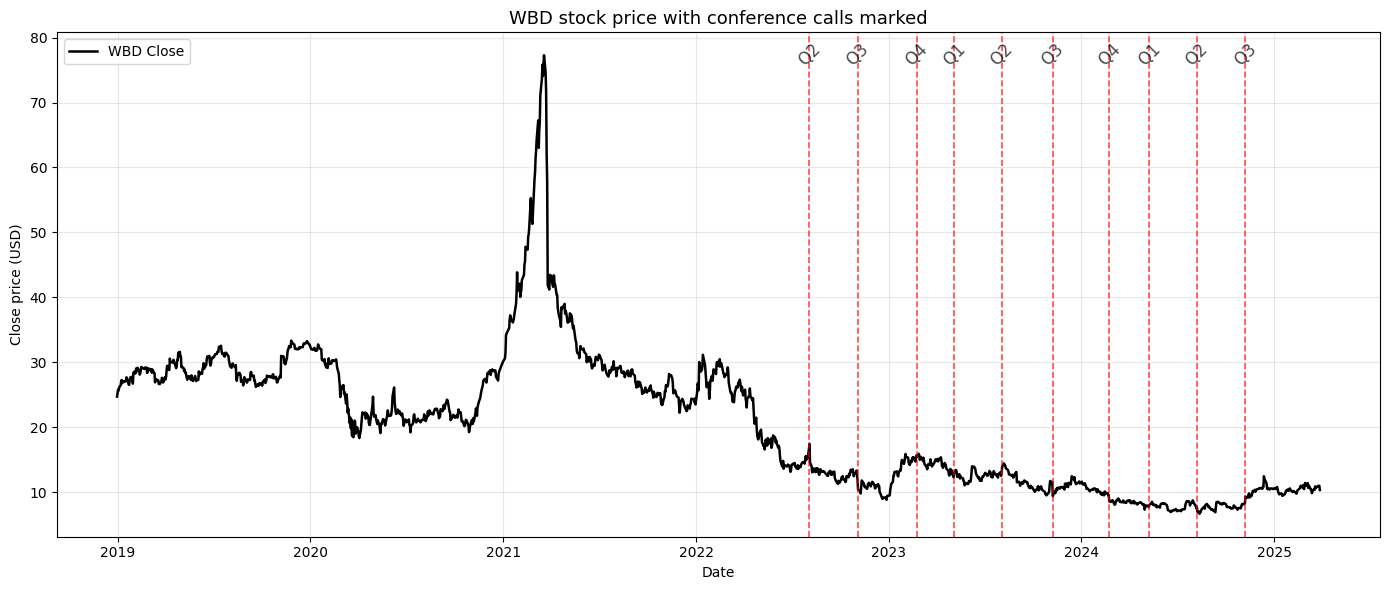

2026-01-06 19:49:51 - multimodal_fin.financial.pipeline - INFO - [WBD] Plotted stock evolution with 10 conference markers from 2018-12-31 to 2025-03-28.


In [15]:
# Visualize stock price evolution for companies with significant results

for ticker in summary_all[(summary_all['p_value'] <= 0.05)]['ticker'].unique():
    pipeline.plot_stock_conferences_evolution(
        ticker=ticker,
        show_quarters=True
    )

# Study mean CAR for companies with evidence across windows

The chart shows how the average cumulative abnormal return (CAR) evolves across different event windows — from short-term (−7, +7 days) to longer horizons (−7, +90 days) — for the subset of companies that exhibited statistical significance (p < 0.05) in at least one window.

A clear pattern emerges for most firms:

Short-term reactions tend to display stronger deviations from zero, indicating initial market overreactions or sharp responses to earnings announcements.

As the window widens (moving to 30, 60, and 90 days), the average CARs for most companies converge back toward zero, suggesting that the initial abnormal price effects dissipate over time — consistent with a market correction once new information is fully absorbed.

This behavior supports the notion that, while some firms experience significant short-term price movements, these effects are generally not sustained in the medium term.

The case of WBD stands out as an exception:

Its CAR shows a monotonic upward trend, increasing steadily with longer windows.

This indicates a persistent positive drift following the event, suggesting that either the market underreacted initially, or the event signaled longer-term positive expectations that continued to be priced in over subsequent months.

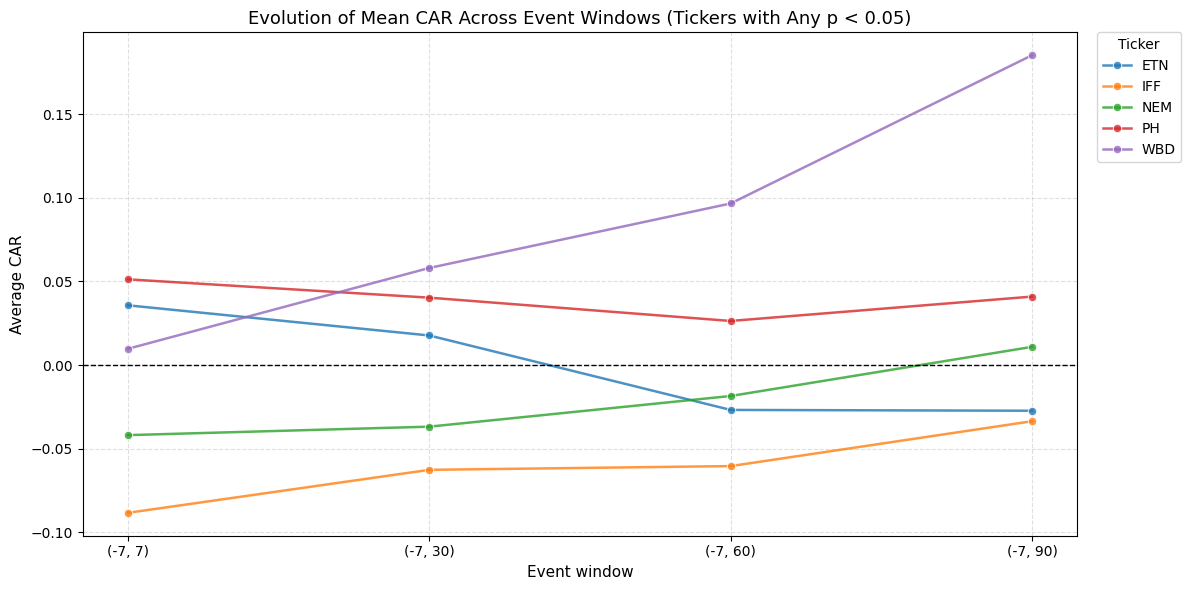

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Identify tickers with at least one significant p-value ---
sig_tickers = summary_all.loc[summary_all["p_value"] < 0.05, "ticker"].unique()
if len(sig_tickers) == 0:
    raise ValueError("No companies with p < 0.05 in any window.")

# Filter main DataFrame to include all observations for those tickers ---
df_plot = summary_all[summary_all["ticker"].isin(sig_tickers)].copy()

# Ensure proper ordering of event windows ---
order = ["(-7, 7)", "(-7, 30)", "(-7, 60)", "(-7, 90)"]
df_plot["car_window"] = pd.Categorical(df_plot["car_window"], categories=order, ordered=True)

# --- 4️⃣ Plot CAR evolution ---
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_plot,
    x="car_window",
    y="mean_CAR",
    hue="ticker",
    marker="o",
    linewidth=1.8,
    alpha=0.8
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Evolution of Mean CAR Across Event Windows (Tickers with Any p < 0.05)", fontsize=13)
plt.xlabel("Event window", fontsize=11)
plt.ylabel("Average CAR", fontsize=11)
plt.legend(title="Ticker", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
